## Objective

The objective of this notebook is to perform a comprehensive evaluation of the selected Random Forest model trained on the SMOTE-balanced dataset. Beyond summary metrics such as Accuracy and F1-score, this notebook examines ROC and Precision-Recall curves, feature importance, and prediction errors to better understand the model's strengths, weaknesses, and suitability for deployment in a fraud detection system.

## Import Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

## Load the Best Model

In [2]:
rf_smote_model = joblib.load(
    "../models/random_forest_smote.pkl"
)

## Load Test Data

In [3]:
X_test = pd.read_csv("../data/processed/X_test.csv")

y_test = (
    pd.read_csv("../data/processed/y_test.csv")
      .squeeze()
)

In [4]:
y_pred = rf_smote_model.predict(X_test)

y_prob = rf_smote_model.predict_proba(X_test)

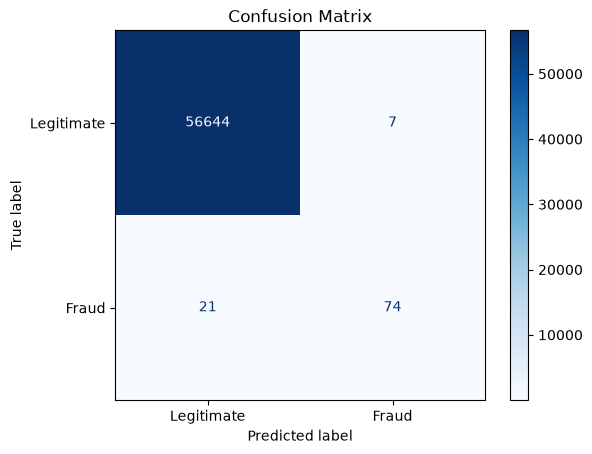

In [6]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

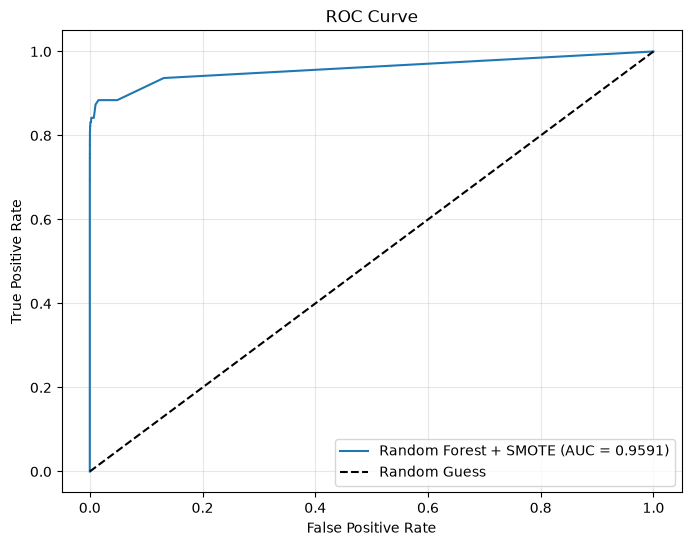

In [9]:
# Probability of fraud
y_prob = rf_smote_model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Random Forest + SMOTE (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

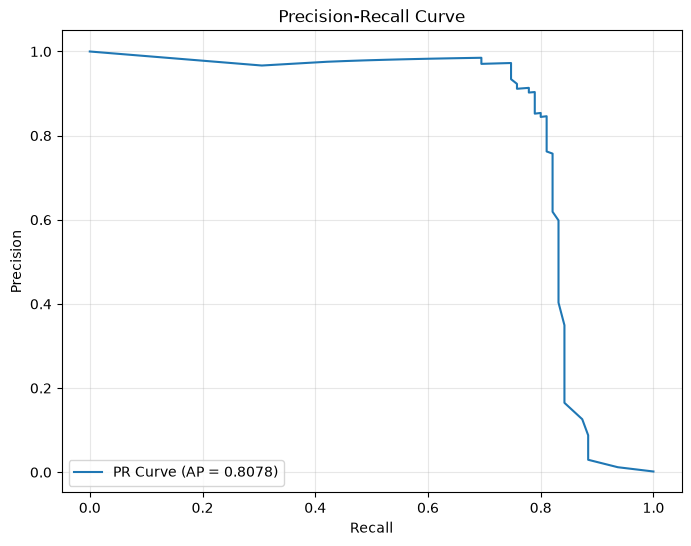

In [10]:

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"PR Curve (AP = {ap:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [11]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": rf_smote_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
14,V14,0.198523
10,V10,0.120442
12,V12,0.095264
4,V4,0.094824
17,V17,0.091017
11,V11,0.057918
16,V16,0.056342
3,V3,0.053910
2,V2,0.037979
9,V9,0.025577


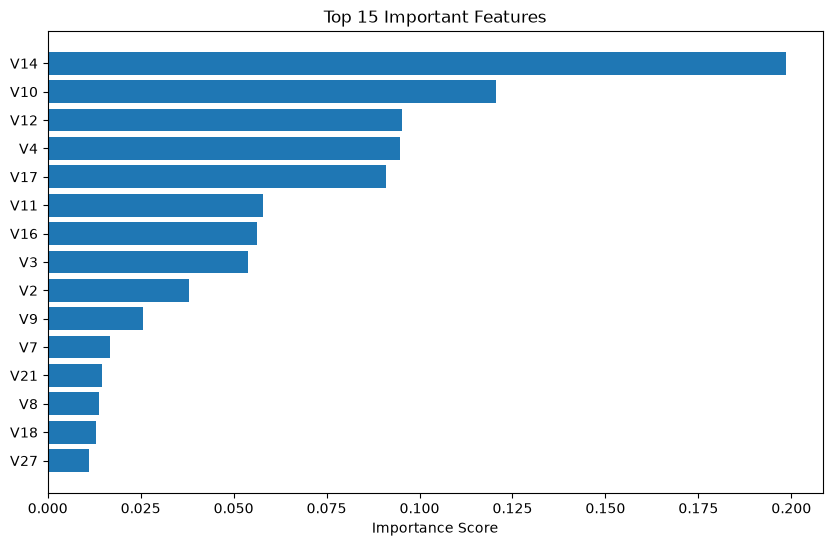

In [12]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")

plt.show()

In [13]:
false_negatives = X_test[
    (y_test == 1) &
    (y_pred == 0)
]

false_negatives.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
1784,0.771570,1.852889,1.069593,-1.776101,4.617410,0.770413,-0.400859,-0.040970,0.089510,-0.217705,...,-0.288392,-0.157869,-0.176244,0.027437,-0.468006,0.058063,0.148263,0.042278,0.040573,-0.292129
4480,0.816388,-0.082983,-3.935919,-2.616709,0.163310,-1.400952,-0.809419,1.501580,-0.471000,1.519743,...,1.878612,0.702672,-0.182305,-0.921017,0.111635,-0.071622,-1.125881,-0.170947,0.126221,14.896203
5187,-0.372874,1.296231,0.417447,0.193963,0.901644,0.130531,-0.371634,0.158126,-0.202669,-0.079512,...,-0.029559,-0.112114,-0.220002,-0.121022,-0.440454,0.671540,-0.413518,0.032838,0.020600,-0.289634
5505,-0.272196,-1.522305,1.505152,0.372364,2.286869,-0.526519,0.998593,-1.087556,-0.027248,-0.533001,...,0.412801,0.332216,0.493981,-0.080198,-0.253327,-0.477800,0.991740,-0.952554,-0.390364,-0.042129
10087,0.028030,-0.419820,-1.155978,-2.092516,2.786750,0.736297,-0.167292,1.600027,-0.117427,-0.796954,...,1.275358,0.480640,0.533517,1.284645,0.516131,-0.602941,-0.305024,-0.021363,0.129096,5.947755


In [14]:
false_positives = X_test[
    (y_test == 0) &
    (y_pred == 1)
]

false_positives.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
6392,0.730559,1.461443,-0.582645,-2.297665,1.089190,0.054096,-1.349453,0.724947,-0.429395,0.788068,...,0.407291,0.008577,-0.314868,-0.188230,-0.098629,0.084687,-0.328303,-0.036457,0.041937,3.798919
9103,-0.787418,-2.609041,4.491900,-8.464528,5.694329,-4.134669,-3.078408,-7.712666,2.243851,-3.390192,...,1.520723,1.551198,-0.212868,0.233113,-0.045893,-0.075365,-0.313185,1.974123,0.813181,0.941103
33810,-0.107022,-4.261226,2.809298,-3.698694,3.802798,-3.573280,-1.403479,-4.889563,1.684010,-2.731574,...,0.389387,0.967389,-0.042429,-0.254398,0.292597,0.098770,-0.331993,0.576056,0.847693,1.217018
41808,0.430133,1.939116,0.085098,-2.662975,0.435701,1.168993,-0.022729,0.229745,-0.036004,0.602997,...,0.011579,-0.154346,-0.320491,-0.085629,-0.524722,0.283720,-0.285547,0.001860,-0.009931,0.595759
49255,-0.130976,-3.423854,1.579438,-1.338452,1.012327,-1.363651,-1.063367,-1.643178,0.783429,-0.356442,...,0.073917,0.002688,-0.683665,0.209910,-0.031626,-0.071505,0.048280,-0.225216,-0.189759,-0.181402


In [15]:
print("False Positives :", len(false_positives))
print("False Negatives :", len(false_negatives))

False Positives : 7
False Negatives : 21


In [16]:
false_negatives.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,...,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000,21.000000
mean,0.005092,-0.483646,-0.274225,-0.409168,2.081285,0.913637,-0.499019,-0.453653,-0.613570,-0.094139,...,0.162775,0.267650,-0.177793,-0.564751,-0.205998,-0.096584,-0.087613,0.050652,0.064881,2.362673
std,0.536707,1.874515,2.381280,1.307458,1.977564,3.305616,1.896859,2.696767,1.497738,1.016093,...,1.057153,1.497626,0.657527,3.605812,0.519085,0.994173,0.500803,0.388521,0.205685,4.265409
min,-0.943981,-5.766879,-8.402154,-3.515730,-1.313275,-1.901763,-5.773192,-9.378025,-6.333065,-1.832604,...,-1.463994,-1.328132,-1.276909,-15.981649,-1.051685,-3.536716,-1.125881,-0.952554,-0.390364,-0.305987
25%,-0.374543,-1.522305,-1.155978,-0.748406,0.756424,-0.568122,-0.781871,-1.087556,-0.446456,-0.796954,...,-0.288392,-0.294166,-0.632078,-0.132568,-0.468006,-0.300896,-0.453206,-0.018287,-0.013923,-0.293237
50%,-0.199231,-0.114361,0.407227,-0.168438,1.493958,0.130531,-0.167292,0.158126,-0.233403,-0.217705,...,-0.032500,-0.051660,-0.176244,-0.080198,-0.242276,0.209178,-0.194419,0.039566,0.048084,-0.275222
75%,0.542841,1.036639,1.069593,0.372364,3.128243,0.685448,0.654937,1.057480,0.023308,0.580415,...,0.732852,0.480640,0.189311,0.172726,0.254719,0.456090,0.193490,0.073269,0.129096,4.128603
max,0.953508,1.894036,2.629739,1.984405,6.950983,11.095089,1.548619,3.071892,0.721743,1.992110,...,2.493224,6.215514,1.196428,2.241471,0.665346,0.696668,0.991740,1.214588,0.583799,14.896203


In [17]:
false_positives.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,-0.113690,-2.528182,1.749148,-4.475872,2.406911,-2.443221,-1.390672,-2.816606,1.307292,-1.145045,...,0.308576,0.492820,-0.306109,-0.215615,-0.118510,0.041524,-0.078346,0.624517,0.184796,2.628465
std,0.534514,3.149849,2.726253,3.414803,2.115657,2.399581,1.496777,3.733050,1.827260,1.697573,...,0.844427,0.659540,0.285598,0.526131,0.262061,0.194773,0.472531,0.788427,0.510342,4.485012
min,-0.787418,-6.691666,-1.787538,-10.169744,0.435701,-5.086248,-3.483809,-7.712666,-0.429395,-3.390192,...,-1.189066,-0.154346,-0.683665,-1.331081,-0.524722,-0.270780,-0.331993,-0.225216,-0.530257,-0.292129
25%,-0.465553,-4.186637,-0.248774,-6.081611,0.805964,-4.151230,-2.240943,-6.045899,0.020015,-2.611971,...,0.042748,0.005633,-0.485176,-0.221314,-0.231971,-0.073435,-0.320744,-0.017298,-0.099845,0.207178
50%,-0.130976,-3.423854,1.579438,-2.699048,1.089190,-3.573280,-1.349453,-1.643178,0.783429,-0.435802,...,0.389387,0.108684,-0.314868,-0.092988,-0.055988,0.084687,-0.286647,0.576056,0.041937,0.941103
75%,0.161555,-0.573799,3.650599,-2.480320,4.008613,-0.654777,-0.543048,0.477346,1.963930,0.123277,...,0.676746,0.966469,-0.127649,0.062140,-0.038759,0.169957,-0.118633,1.040625,0.566944,2.507968
max,0.730559,1.939116,5.648488,-1.338452,5.694329,1.168993,0.666540,0.776705,4.829117,0.788068,...,1.520723,1.551198,0.081421,0.233113,0.292597,0.283720,0.948976,1.974123,0.847693,12.319983


The Random Forest model trained on SMOTE-balanced data demonstrated excellent discrimination between fraudulent and legitimate transactions, achieving an ROC-AUC of 0.9591 and a PR-AUC of 0.8078. Feature importance analysis identified the most influential predictors used during classification. Error analysis showed that the model correctly detected 74 of 95 fraudulent transactions, missing 21 fraud cases while incorrectly flagging 7 legitimate transactions. These findings indicate strong overall performance while highlighting opportunities for further improvement through threshold tuning and hyperparameter optimization.